In [1]:
import numpy as np
import pandas as pd

In [2]:
p=pd.read_csv("/content/i1.csv")
a=pd.read_csv("/content/i2.csv")
p.shape

(7242, 16)

In [3]:
a.shape

(8379, 16)

In [4]:
g=p.merge(a,how='outer')
g.shape

(15621, 16)

In [5]:
g.describe()


,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [6]:
g.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [7]:
g.isnull().sum()

,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [8]:
g.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [9]:
g = g.drop(columns=["Discount", "Covers", "Table No.", "Server Name", "Variation", "HSN"], errors='ignore')
g.shape

(15621, 10)

In [10]:
h=g['Final Total'].sum()
print(h)

2397010.12


In [11]:
f=g['Invoice No.'].nunique()
print(f)

4925


In [12]:
ad=h/f
print(ad)


486.70256243654825


In [13]:
c=g.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]
print(c)


Item Name
Mineral Water                             1672.0
Chicken Biriyani With Raitha And Gravy    1453.0
Butter Naan                               1046.0
Romali Roti (1 No)                         822.0
Lemon Soda                                 722.0
Name: Qty., dtype: float64


<Axes: xlabel='Item Name', ylabel='Qty.'>

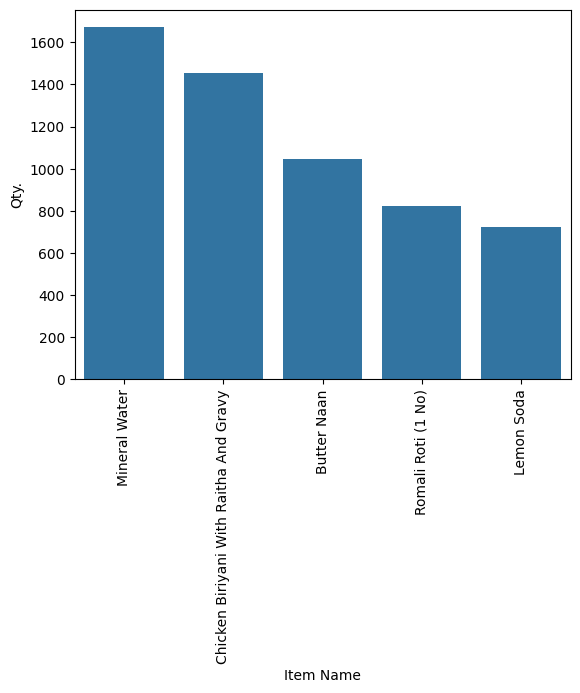

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns
c.plot(kind='bar')
sns.barplot(c)

<Axes: ylabel='Qty.'>

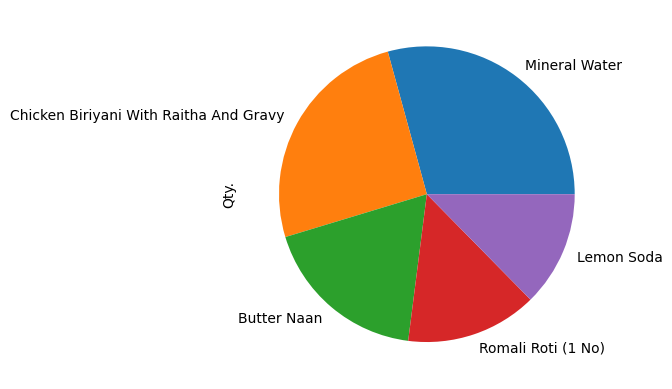

In [15]:


c.plot(kind='pie')

Item Name
Chicken Biriyani With Raitha And Gravy    240730.96
Chicken Fried Rice                        119347.20
Butter Naan                                65387.74
Thandoor Chicken Half                      53185.83
Paneer Butter Masala                       49581.22
Chicken Lolly Pop                          48437.66
Chicken 65                                 48281.92
Pepper Tandoori Chicken ( Half )           45886.61
Dragon Chicken                             44219.72
Butter Chicken Gravy                       44098.58
Name: Final Total, dtype: float64


<Axes: xlabel='Item Name'>

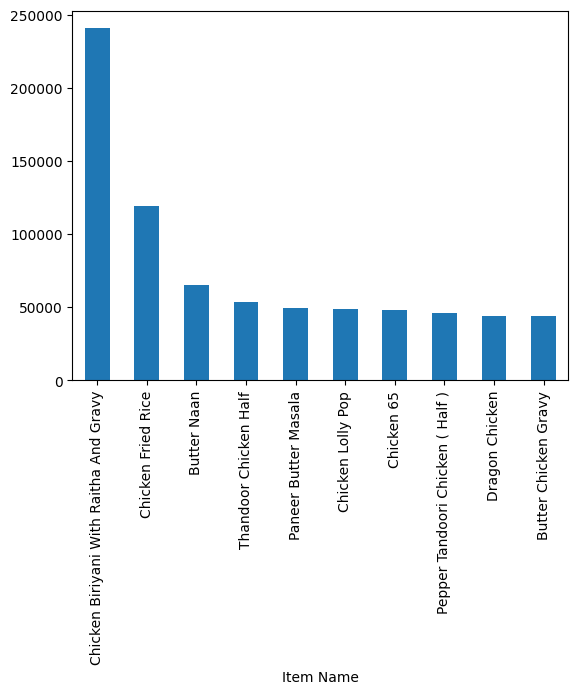

In [16]:

e=g.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:10]
print(e)
e.plot(kind='bar')

In [17]:

d=g[g['Date']=='2023-09-15']['Qty.'].sum()
print(d)

186.0


In [18]:
g.groupby('Date')['Qty.'].sum().loc["2023-09-15"]

np.float64(186.0)

In [19]:
s=g[(g['Date']=='2023-09-15')&(g['Item Name']=='Chicken Noodles')]['Qty.'].sum()
print(s)

7.0


In [23]:
d=g.groupby('Invoice No.')['Final Total'].sum().loc[lambda x:x>2000]
print(d)

Invoice No.
23499     2533.64
23508     2011.00
23637     5644.82
23718     3517.50
23827    22638.00
           ...   
28014     3013.68
28126     2887.50
28145     4078.68
28259     4291.36
28315     2004.44
Name: Final Total, Length: 162, dtype: float64


In [24]:
d=g.groupby('Invoice No.')['Final Total'].sum()
d=d[d>2000]
print(d)

Invoice No.
23499     2533.64
23508     2011.00
23637     5644.82
23718     3517.50
23827    22638.00
           ...   
28014     3013.68
28126     2887.50
28145     4078.68
28259     4291.36
28315     2004.44
Name: Final Total, Length: 162, dtype: float64


In [25]:

d=g['Final Total'].sum()
print(d)

2397010.12
